<a href="https://colab.research.google.com/github/kdkim2000/RAG2026/blob/main/%5B%EA%B0%95%EC%9D%98%EB%82%B4%EC%9A%A9%5D_6_Advanced_RAG%2BRAG%EC%84%B1%EB%8A%A5%ED%8F%89%EA%B0%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [실습] RAG 성능 평가와 Advanced RAG

RAG의 기본 베이스 체인에서 시작하여, 다양한 기능을 추가해 보겠습니다.

In [ ]:
%pip install ragas==0.4.0 sacrebleu dotenv jsonlines openai langchain langchain-openai langchain_qdrant 'langchain-community<0.4.2' tiktoken rank_bm25 pymupdf kiwipiepy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 9.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.1/397.1 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.1/122.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.1/398.1 kB 24.2 MB/s eta 0:00:00
   ━━━━━

In [ ]:
import os
from dotenv import load_dotenv
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from openai import OpenAI
from glob import glob
# 시스템/유틸리티
import os
import gc
import ast
import csv
import uuid
import datetime
import re

# API & 환경 설정
import openai
from openai import AsyncOpenAI
from dotenv import load_dotenv

# 데이터 처리 및 시각화
import pandas as pd
from tqdm import tqdm
from glob import glob

# 네트워크/웹 관련
import requests
import jsonlines
import bs4

from langchain_openai import OpenAIEmbeddings, ChatOpenAI

# LangChain 핵심 모듈
from langchain_community.document_loaders import PyMuPDFLoader, TextLoader
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough, RunnableParallel
from langchain_core.output_parsers import StrOutputParser
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Ragas 평가/지표 관련
from ragas import EvaluationDataset, evaluate
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import OpenAIEmbeddings as RagasOpenAIEmbeddings
from ragas.metrics.collections import (
    ContextRecall,
    Faithfulness,
    FactualCorrectness,
    BleuScore,
    SemanticSimilarity
)

import logging

# OpenAI, httpx의 INFO 로그 차단
logging.getLogger("openai").setLevel(logging.WARNING)
logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("httpcore").setLevel(logging.WARNING)

# RAGAS 사용 정보 수집 차단
os.environ["RAGAS_DO_NOT_TRACK"] = "true"
os.environ["DISABLE_TELEMETRY"] = "1"
os.environ["DO_NOT_TRACK"] = "1"

load_dotenv(override=True)

True

LLM을 준비합니다.

In [ ]:
llm = ChatOpenAI(model='gpt-5.2', reasoning_effort='low')
print(llm.invoke("안녕?").text)

안녕하세요! 무엇을 도와드릴까요?


RAG_data.zip을 업로드하고, 압축을 해제합니다.

In [ ]:
import zipfile
import os

# 압축 파일 이름 (현재 위치)
zip_filename = "RAG_data.zip"

# 압축 해제 경로 (data 폴더)
extract_path = "data"

try:
    # data 폴더 없으면 생성
    os.makedirs(extract_path, exist_ok=True)

    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    print(f"성공: {zip_filename}의 압축을 {extract_path}/ 폴더에 풀었습니다.")

except FileNotFoundError:
    print(f"오류: {zip_filename} 파일을 찾을 수 없습니다.")

except zipfile.BadZipFile:
    print("오류: 손상되었거나 유효하지 않은 zip 파일입니다.")

성공: RAG_data.zip의 압축을 data/ 폴더에 풀었습니다.


In [ ]:
# 데이터 준비 / 전처리 / 벡터 데이터베이스 구성
def preprocess(docs):
    import re
    def clean_text(doc):
        text = doc.page_content
        text1 = re.sub(r'&[a-zA-Z0-9#]+;', '', text)
        text = text1
        text2 = re.sub(r'[\u200b\u00a0]', '', text)
        text = text2
        text3 = re.sub(r' {2,}', ' ', text2)
        text = text3.strip()
        doc.page_content = text
        return doc
    preprocessed_docs = []
    for doc in docs:
        doc = clean_text(doc)
        preprocessed_docs.append(doc)
    return preprocessed_docs

reports = glob('data/markdowns/*.md')
documents = []
for report in reports:
    loader = TextLoader(report)
    docs = loader.load()
    print('문서 로드 완료:', docs[0].metadata, docs[0].page_content[0:10], '...', len(docs[0].page_content))
    documents += docs
documents = preprocess(documents)

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
# 0~1000, 800~1800, 1600~2600, ...
chunks = text_splitter.split_documents(documents)
print(f'# 총 {len(chunks)} 개의 청크 생성')

문서 로드 완료: {'source': 'data/markdowns/SPRi AI Brief_1월호_산업동향_0102_F.md'} 인공지능 산업의 최 ... 41926
문서 로드 완료: {'source': 'data/markdowns/SPRi AI Brief_12월호_산업동향_1208_F.md'} ## 인공지능 산업 ... 39817
문서 로드 완료: {'source': 'data/markdowns/[2025.12 하나금융연구소](하나 Knowledge 25-38호) 금융투자업계에 스미는 AI.md'} ## 금융투자업계에 ... 14665
문서 로드 완료: {'source': 'data/markdowns/SPRi AI Brief_10월호_산업동향_1002_F.md'} 인공지능 산업의 최 ... 42825
문서 로드 완료: {'source': 'data/markdowns/[2025.12 구글]google_cloud_ai_agent_trends_2026_report.md'} ## AI agen ... 32781
문서 로드 완료: {'source': 'data/markdowns/[2025.12 삼일회계법인]2026대한민국산업지도.md'} ## 정부의전략산업 ... 112335
문서 로드 완료: {'source': 'data/markdowns/SPRi AI Brief_11월호_산업동향_1105_F.md'} 인공지능 산업의 최 ... 42931
# 총 415 개의 청크 생성


Qdrant Vector Store를 통해 DB를 구성합니다.

In [ ]:
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams


openai_embeddings = OpenAIEmbeddings(model='text-embedding-3-large',
                                     chunk_size=100)

uuidstr = str(uuid.uuid4())[0:6]
client = QdrantClient(path=f"outputs/vectordb/qdrant_{uuidstr}")

client.create_collection(
    collection_name=f"AI_Reports",
    vectors_config=VectorParams(size=3072, distance=Distance.EUCLID))

vector_store = QdrantVectorStore(
    client=client,
    collection_name=f"AI_Reports",
    embedding=openai_embeddings,
    distance=Distance.EUCLID)

vector_store.add_documents(chunks)

retriever = vector_store.as_retriever(search_kwargs={"k": 5})
print("벡터 DB와 Retriever 준비 완료!")

벡터 DB와 Retriever 준비 완료!


이전 실습과 유사하게, 프롬프트를 구성합니다.

In [ ]:
from typing import Iterable, Sequence
from xml.sax.saxutils import escape
from langchain_core.documents import Document

def format_docs(
    docs: Iterable[Document],
    metadata_keys: Sequence[str] = ("source",),
) -> str:
    """
    List[Document] -> XML 직렬화 문자열.

    - 청크 경계: <document index="N"> 태그로 명시
    - 메타데이터: metadata_keys 에 지정한 키만 <meta>로 포함 (누락 키는 자동 생략)
    - 본문: XML 특수문자 escape (본문에 '<', '>' 가 있어도 경계 유지)
    """
    parts: list[str] = ["<documents>"]
    for i, doc in enumerate(docs, start=1):
        parts.append(f'  <document index="{i}">')
        for key in metadata_keys:
            value = doc.metadata.get(key)
            if value is None:
                continue
            parts.append(
                f'    <meta name="{escape(str(key))}">{escape(str(value))}</meta>'
            )
        parts.append(f"    <content>{escape(doc.page_content)}</content>")
        parts.append("  </document>")
    parts.append("</documents>")
    return "\n".join(parts)

prompt = ChatPromptTemplate([
    ("system", '''당신은 QA(Question-Answering)을 수행하는 Assistant입니다.
다양한 출처의 보고서 일부 내용이 Context로 주어집니다.
Context의 내용을 바탕으로 Question에 대한 답변을 제공하세요.

만약 Context가 질문과 무관하거나 관련 정보가 없다면,
"정보가 부족하여 답변할 수 없습니다."를 출력하세요.'''),
    ("human",'''Context: {context}
---
Question: {question}''')])


rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser())

print("RAG 체인 준비 완료!")

RAG 체인 준비 완료!


# RAG 성능 평가하기   

구성한 RAG의 성능은 어떻게 평가할까요?   

RAGAS (https://docs.ragas.io/en/stable/)는 다양한 메트릭을 통한 RAG의 성능 평가를 지원합니다.

RAG의 평가를 위해서는 정답이 있는 Q/A 데이터가 필요합니다.   
실습 시트에서 eval.jsonl을 다운로드하여 불러옵니다.

In [ ]:
import pandas as pd
df = pd.read_csv('data/evaluation/rag_evaluation_data.csv')

eval_dataset = df.to_dict('list')
questions, ground_truths, qtypes = eval_dataset['question'], eval_dataset['answer'], eval_dataset['difficulty']
for i in range(len(questions)):
    print(f'#{i} ', end='')
    print(f'({qtypes[i]})')
    print(f'Question: {questions[i]}\n')
    print(f'Ground Truth: {ground_truths[i]}\n')
    print('-----------')

#0 (Easy)
Question: 1X가 출시한 가정용 휴머노이드 로봇 네오의 예약 판매 가격과 배송 일정은?

Ground Truth: 네오'의 예약 판매 가격은 2만 달러이며, 2026년부터 미국 내 소비자를 대상으로 우선적으로 제품을 배송한 뒤, 2027년부터는 판매 대상 지역을 해외 시장으로 단계적으로 확대할 계획이다. 또한, 추후에는 월 499달러를 지불하는 구독형 서비스 모델도 별도로 제공할 예정이다.

-----------
#1 (Easy)
Question: 구글 리포트에서 말하는 AI 에이전트란 무엇인가요?

Ground Truth: 구글 리포트에서 정의하는 AI 에이전트란,
단순히 질문에 답을 생성하는 AI가 아니라 목표를 이해하고, 그 목표를 달성하기 위한 계획을 세운 뒤, 실제로 여러 시스템과 도구를 넘나들며 행동까지 수행하는 AI 시스템을 의미합니다.

리포트에 따르면 AI 에이전트는 고급 AI 모델의 지능과 외부 도구 및 데이터에 대한 접근 능력을 결합한 시스템으로, 사용자의 통제와 감독 하에 사용자를 대신해 행동할 수 있습니다. 이 때문에 AI 에이전트는 기존의 “보조적인 기능(add-on)”이 아니라, 업무 흐름 자체가 AI를 중심으로 재구성되는 AI-first 프로세스의 핵심 구성 요소로 설명됩니다.

또한 이 리포트는 AI 에이전트를 인간을 대체하는 존재로 보지 않습니다. 오히려 인간은 여전히 목표를 설정하고, 전략을 제시하며, 결과를 검증하는 최종 의사결정자이자 오케스트레이터로 남고, 에이전트는 그 과정을 증폭시키는 역할을 맡는다고 명확히 설명합니다. 즉, AI 에이전트는 스스로 판단해 무작위로 행동하는 존재가 아니라, 인간의 의도와 감독 아래에서 계획·실행·조정을 반복하는 행동 가능한 AI 시스템입니다

-----------
#2 (Easy)
Question: 보고서에서 다뤄진 미국-유럽의 방위 정책 강화 과정에 대해 설명해주세요.

Ground Truth: 보고서는 러?우 전쟁 이후 지정학적 갈등이 장기화되면서 방위비 지출

구성된 RAG 체인을 이용해, RAGAS의 Evaluate에 필요한 데이터를 구성합니다.

In [ ]:
dataset = []

result = rag_chain.batch(questions)
relevant_docs_list = retriever.batch(questions)

for i, ans in enumerate(result):
    print(f"Question: {questions[i]}")

    relevant_docs = [doc.page_content for doc in relevant_docs_list[i]]
    print(f"Answer: {ans}")
    print('---')

    dataset.append(
        {
            "user_input":questions[i],
            "retrieved_contexts":relevant_docs,
            "response":ans,
            "reference":ground_truths[i]
        }
    )

Question: 1X가 출시한 가정용 휴머노이드 로봇 네오의 예약 판매 가격과 배송 일정은?
Answer: 1X의 가정용 휴머노이드 로봇 ‘네오(Neo)’는 **예약 판매 가격이 2만 달러(USD 20,000)**로 책정됐습니다. 배송 일정은 **2026년에 미국 내 소비자에게 우선 배송을 시작**하고, **2027년부터 해외 시장으로 판매(배송) 확대**를 계획하고 있습니다.
---
Question: 구글 리포트에서 말하는 AI 에이전트란 무엇인가요?
Answer: 구글 리포트에서 말하는 **AI 에이전트(AI agent)**는 **고도화된 AI 모델의 지능에 ‘도구(tool) 접근’을 결합해**, 사용자를 대신해(단, **사용자의 통제 하에**) **행동을 수행할 수 있는 시스템**을 의미합니다.  

즉, 단순히 답변만 생성하는 AI를 넘어, 필요한 도구를 활용해 실제로 작업을 “수행”하는 형태로 설명됩니다.
---
Question: 보고서에서 다뤄진 미국-유럽의 방위 정책 강화 과정에 대해 설명해주세요.
Answer: 보고서에서 설명하는 **미국–유럽의 방위정책 강화 과정**은 대체로 다음의 흐름으로 정리됩니다.

1) **촉발 요인: 지정학 리스크의 상수화 + 미국 정책 기조 변화**
- 러–우 전쟁 등으로 **글로벌 지정학 갈등이 지속**되며 방위력 강화가 본격화되었다고 봅니다.
- 여기에 **트럼프 2기 정책 변화(미국 우선주의, ‘세계 경찰’ 역할 축소)**가 더해지면서, 미국이 동맹국에 **자체 방어역량 강화 및 방위비 지출 확대**를 촉구하는 방향으로 압력이 커졌다고 설명합니다.

2) **전쟁 양상 변화: 기술경쟁(사이버·전자전·AI)으로의 전환**
- 전쟁의 영역이 확대되고 무기체계가 고도화되면서, 미래전이 **사이버전·전자전·AI 활용 확대**로 변모하고 있어 **국방 R&D 증액이 필수**라는 문제의식이 제시됩니다.
- 즉, 방위비 확대가 단순 증액이 아니라 **기술 중심의 군 현대화 투자**로 성격이 바뀌는 과정으로 설명합니다.



## RAGAS: RAG 성능 평가 프레임워크
RAGAS는 LLM을 이용해 정답과 답변을 개별 Claim(주장)으로 분할합니다.

이후, `LLMContextRecall`, `Faithfulness`, `FactualCorrectness` 등의 다양한 메트릭을 통해 RAG 파이프라인의 성능을 평가합니다.   
LLM 기반의 방법이므로 평가 LLM의 선정이 중요하며, 절대 수치보다는 상대적 비교가 효과적입니다.


- Context Recall: 정답의 Claim이 검색된 비율
- Faithfulness : 답변의 Claim이 검색 결과에 근거한 정도
- Factual Correctness : 정답과 답변의 Claim 일치도
- Bleu Score : 정답과 답변의 키워드 일치도
- Semantic Sim : 정답과 답변 임베딩의 유사도   


In [ ]:
from ragas import EvaluationDataset
evaluation_dataset = EvaluationDataset.from_list(dataset)
evaluation_dataset

EvaluationDataset(features=['user_input', 'retrieved_contexts', 'response', 'reference'], len=20)

In [ ]:
# Ragas 평가/지표 관련
from ragas import EvaluationDataset, aevaluate, RunConfig
from ragas.llms import llm_factory
from ragas.embeddings import OpenAIEmbeddings as RagasOpenAIEmbeddings
from ragas.metrics import (
    ContextRecall,
    Faithfulness,
    FactualCorrectness,
    BleuScore,
    SemanticSimilarity
)
from langchain_openai import ChatOpenAI
from openai import AsyncOpenAI


# OpenAI 클라이언트 생성
client = AsyncOpenAI()

# https://docs.ragas.io/en/stable/concepts/metrics/available_metrics/

# 평가자 LLM
evaluator_llm = llm_factory('gpt-4.1-mini', client=client, temperature=0.1, max_tokens=8192)

# 평가자 Embedding
evaluator_embeddings = RagasOpenAIEmbeddings(model="text-embedding-3-large", client=client)
semantic_scorer = SemanticSimilarity(embeddings = evaluator_embeddings)

# 20개 질문을 병렬로 평가
run_config = RunConfig(max_workers=32)

print("평가자 준비 완료!")

평가자 준비 완료!


In [ ]:
result = await aevaluate(
    dataset=evaluation_dataset,
    metrics=[
        BleuScore(),
        ContextRecall(),
        semantic_scorer,
        Faithfulness(),
        FactualCorrectness(),
    ],
    llm=evaluator_llm,
    embeddings=evaluator_embeddings,
    run_config=run_config,
)

result

Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]

{'bleu_score': 0.2427, 'context_recall': 0.7017, 'semantic_similarity': 0.8048, 'faithfulness': 0.7701, 'factual_correctness(mode=f1)': 0.6945}

In [ ]:
result.scores[0:3]

[{'bleu_score': 0.03203843891645795,
  'context_recall': 1.0,
  'semantic_similarity': 0.717180287534394,
  'faithfulness': 1.0,
  'factual_correctness(mode=f1)': np.float64(0.86)},
 {'bleu_score': 0.026138404836748817,
  'context_recall': 0.6666666666666666,
  'semantic_similarity': 0.8463757292554334,
  'faithfulness': 1.0,
  'factual_correctness(mode=f1)': np.float64(0.44)},
 {'bleu_score': 0.02948151007490361,
  'context_recall': 1.0,
  'semantic_similarity': 0.8077093639551158,
  'faithfulness': 1.0,
  'factual_correctness(mode=f1)': np.float64(0.77)}]

In [ ]:
detailed_result = result.to_pandas()
os.makedirs('outputs/eval', exist_ok=True)
detailed_result.to_csv('outputs/eval/ragas_result.csv', encoding='utf-8', errors='ignore', index=False)

기본적인 구조의 RAG 성능을 확인해 보았습니다.

평가를 위해, 이후에는 평가 함수를 별도로 구성합니다.

In [ ]:
def rag_answer_batch(questions, rag_chain, retriever):
    """질문 리스트를 받아 (답변 리스트, 근거 컨텍스트 리스트)를 반환합니다."""
    answers = rag_chain.batch(questions)
    contexts = [[doc.page_content for doc in docs] for docs in retriever.batch(questions)]
    return answers, contexts


async def evaluate_rag(name, answer_fn):
    """검색 방식을 바꿔 가며 같은 지표로 비교합니다.

    name: 결과 파일 이름에 사용할 방식 이름
    answer_fn: 질문 리스트를 받아 (답변, 근거 컨텍스트)를 돌려주는 함수
    """
    answers, contexts = answer_fn(questions)

    new_dataset = [
        {
            "user_input": question,
            "retrieved_contexts": context,
            "response": answer,
            "reference": ground_truth,
        }
        for question, context, answer, ground_truth
        in zip(questions, contexts, answers, ground_truths)
    ]

    evaluation_dataset = EvaluationDataset.from_list(new_dataset)

    result = await aevaluate(
        dataset=evaluation_dataset,
        metrics=[
            BleuScore(),
            ContextRecall(),
            semantic_scorer,
            Faithfulness(),
            FactualCorrectness()
        ],
        llm=evaluator_llm,
        embeddings=evaluator_embeddings,
        run_config=run_config
    )

    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    os.makedirs('outputs/eval', exist_ok=True)
    csv_filename = f'outputs/eval/ragas_result_{name}_{timestamp}.csv'
    result.to_pandas().to_csv(csv_filename, encoding='utf-8', errors='ignore', index=False)

    return result

# Multi-Query Retriever   

검색 쿼리를 바로 retrieve하는 대신, 검색 쿼리를 미리 생성합니다.   


In [ ]:
# Multi Query를 확인하기 위한 로깅
import logging

logging.basicConfig()
logging.getLogger('langchain_classic.retrievers.multi_query').setLevel(logging.INFO)

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_classic.retrievers.multi_query import MultiQueryRetriever


rewrite_prompt = ChatPromptTemplate([
    ('system','''Retrieval Augmented Generation을 위해,
주어진 질문에 정확한 답변을 수행하기 위한 검색 쿼리를 작성하세요.
원본 질문을 포함해, 사용자의 질문을 해결하기 위해 검색해야 하는 4개의 쿼리를 한 줄에 하나씩 출력하세요.
'구글'에 관한 질문의 경우에는 영문 질문을 포함하세요.
각 질문들은 완성된 질문 형태로 생성하고, 한 줄에 하나씩 새로운 줄로 구분하여 제공하세요.'''),
    ('human','''
---
원본 질문: {question}''')])

multi_query_retriever = MultiQueryRetriever.from_llm(
    retriever=vector_store.as_retriever(),
    llm=llm,
    prompt = rewrite_prompt,
)
# llm + prompt로 초기 질문을 4개로 확장 --> 각각 검색 후 중복 제거

In [ ]:
enhanced_context = multi_query_retriever.invoke("트럼프 미국 대통령이 서명한 '제네시스 미션' 행정명령의 핵심 목표는 무엇인가요?")

len(enhanced_context)

INFO:langchain_classic.retrievers.multi_query:Generated queries: ['트럼프 미국 대통령이 서명한 ‘제네시스 미션(Genesis Mission)’ 행정명령의 핵심 목표는 무엇인가요?  ', '트럼프 ‘제네시스 미션(Genesis Mission)’ 행정명령 내용과 목표는 무엇이며 어떤 정책을 지시했나요?  ', '“Genesis Mission” executive order signed by President Trump main goal and key objectives  ', '‘제네시스 미션(Genesis Mission)’ 행정명령 원문(백악관/연방관보)과 요약을 어디서 확인할 수 있고 핵심 조항은 무엇인가요?']


7

In [ ]:
multiquery_rag_chain = (
    {"context": multi_query_retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

In [ ]:
await evaluate_rag('multiquery', lambda qs: rag_answer_batch(qs, multiquery_rag_chain, multi_query_retriever))

INFO:langchain_classic.retrievers.multi_query:Generated queries: ['1X가 출시한 가정용 휴머노이드 로봇 ‘네오(NEO)’의 예약 판매(사전예약) 가격은 얼마인가?  ', 'What is the pre-order price of 1X’s home humanoid robot NEO?  ', '1X ‘네오(NEO)’의 예약 판매(프리오더) 시작일과 예상 배송(출고) 일정은 언제인가?  ', 'When will 1X’s NEO home humanoid robot start shipping and what is the expected delivery timeline?']
INFO:langchain_classic.retrievers.multi_query:Generated queries: ['삼일회계법인 산업지도에서 “ABCDE+2S”의 의미는 무엇인가요?  ', '삼일회계법인(PwC Korea) 산업지도에서 산업 분류/등급 체계 “A B C D E + 2S”의 정의와 평가 기준은 무엇인가요?  ', 'PwC Korea(삼일회계법인) “산업지도(Industry Map)” 문서/보고서에서 “ABCDE+2S” 표기 설명이 어디에 있나요?  ', 'What does “ABCDE+2S” mean in PwC Korea (Samil PwC) Industry Map / industry map report?']
INFO:langchain_classic.retrievers.multi_query:Generated queries: ['트럼프 미국 대통령이 서명한 ‘제네시스 미션(Genesis Mission)’ 행정명령의 핵심 목표는 무엇인가요?  ', 'Trump executive order “Genesis Mission” 핵심 목표는 무엇이며 어떤 정책을 지시하나요?  ', '‘Genesis Mission’ 행정명령 전문(원문)과 주요 조항(목적, 범위, 실행기관)은 무엇인가요?  ', '트럼프 ‘Genesis Mission’ 행정명령

Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]

{'bleu_score': 0.2530, 'context_recall': 0.8400, 'semantic_similarity': 0.8405, 'faithfulness': 0.8112, 'factual_correctness(mode=f1)': 0.7360}


### Ensemble Retriever

Lexical 검색인 BM25와 Semantic 검색인 임베딩 방법을 조합할 수도 있습니다.    
기본 BM25 리트리버는 한국어 처리가 어려우므로, Kiwi 형태소 분석기를 사용합니다.

In [ ]:
from kiwipiepy import Kiwi

kiwi = Kiwi()
# Kiwi 형태소 분석기: 고유명사를 추가할 수도 있음
def kiwi_tokenize(text):
    return [token.form for token in kiwi.tokenize(text)]

kiwi_tokenize(chunks[10].page_content)


['-',
 'n',
 '호주',
 '산업',
 '과학',
 '자원부',
 '(',
 'DISR',
 ')',
 '가',
 '경쟁력',
 '과',
 '생산',
 '성',
 ',',
 '복원력',
 '을',
 '갖추',
 'ᆫ',
 'AI',
 '기반',
 '경제',
 '구축',
 '을',
 '통하',
 '어',
 '호주',
 '국민',
 '전체',
 '에',
 '실질',
 '적',
 '혜택',
 '을',
 '제공',
 '하',
 '기',
 '위하',
 'ᆫ',
 "'",
 '국가',
 'AI',
 '계획',
 '(',
 'National',
 'AI',
 'Plan',
 ')',
 "'",
 '을',
 '수립',
 '-',
 '국가',
 'AI',
 '계획',
 '은',
 '①',
 '기회',
 '포착',
 '(',
 'Capture',
 'the',
 'opportunities',
 ')',
 '②',
 '혜택',
 '확산',
 '(',
 'Spread',
 'the',
 'benefits',
 ')',
 '③',
 '안전',
 '확보',
 '(',
 'Keep',
 'Australians',
 'safe',
 ')',
 '이',
 '라는',
 '3',
 '대',
 '목표',
 '하',
 '의',
 '9',
 '개',
 '실행',
 '과제',
 '로',
 '구성',
 '-',
 'n',
 '(',
 '기회',
 '포착',
 ')',
 '호주',
 '국민',
 '이',
 'AI',
 '의',
 '기회',
 '를',
 '포착',
 '하',
 '어',
 '직장',
 '과',
 '사회',
 ',',
 '일상',
 '에서',
 'AI',
 '를',
 '최대한',
 '활용',
 '하',
 'ᆯ',
 '수',
 '있',
 '도록',
 '지원',
 '하',
 '고자',
 '△',
 '스마트',
 '인프라',
 '구축',
 '△',
 '호주',
 'AI',
 '역량',
 '강화',
 '△',
 '투자',
 '유치',
 '의',
 '3',
 '개',
 '실행',
 '과제',


In [ ]:
from langchain_classic.retrievers import BM25Retriever, EnsembleRetriever

# BM25: 단어의 중요도에 따라 가중치를 부여하는 인덱싱 방법
bm25_retriever = BM25Retriever.from_documents(chunks, preprocess_func = kiwi_tokenize)
bm25_retriever.k = 5

retriever = vector_store.as_retriever(search_kwargs={"k": 5})

ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, retriever], weights=[0.5, 0.5]
    # 합집합
)

In [ ]:
ensemble_rag_chain = (
    {"context": ensemble_retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

In [ ]:
await evaluate_rag('ensemble', lambda qs: rag_answer_batch(qs, ensemble_rag_chain, ensemble_retriever))

Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]

{'bleu_score': 0.2611, 'context_recall': 0.7233, 'semantic_similarity': 0.8440, 'faithfulness': 0.7514, 'factual_correctness(mode=f1)': 0.7300}

### Reranker

High K로 검색한 후보 청크를 다시 정렬해, 관련도가 높은 청크만 남기는 단계입니다.

리랭커는 쿼리와 청크의 관련도를 직접 출력하는 모델을 쓰는 방법과, LLM에게 점수를 매기게 하는 방법이 있습니다.
여기서는 LLM 리랭커를 사용합니다.

In [ ]:
from langchain_core.retrievers import BaseRetriever
from langchain_core.runnables import Runnable
from typing import List

rerank_prompt = ChatPromptTemplate([
    ('system', '''질문에 답하는 데 문서가 얼마나 도움이 되는지 0에서 10 사이의 정수로 평가하세요.
숫자만 출력하세요.'''),
    ('human', '''질문: {question}
---
문서: {document}''')
])

rerank_chain = rerank_prompt | llm | StrOutputParser()


def parse_score(text):
    matched = re.search(r'\d+', text)
    return int(matched.group()) if matched else 0


class LLMRerankRetriever(BaseRetriever):
    """후보 문서를 LLM이 매긴 점수 순으로 정렬해 상위 top_k개를 반환합니다."""
    base_retriever: BaseRetriever
    reranker: Runnable
    top_k: int = 5

    def _get_relevant_documents(self, query: str, *, run_manager=None) -> List[Document]:
        candidates = self.base_retriever.invoke(query)
        scores = self.reranker.batch(
            [{'question': query, 'document': doc.page_content} for doc in candidates]
        )
        ranked = sorted(zip(candidates, scores), key=lambda pair: parse_score(pair[1]), reverse=True)
        return [doc for doc, score in ranked[:self.top_k]]

In [ ]:
# 리랭킹할 후보를 넉넉히 검색합니다
bm25_candidates = BM25Retriever.from_documents(chunks, preprocess_func=kiwi_tokenize)
bm25_candidates.k = 8

candidate_retriever = EnsembleRetriever(
    retrievers=[bm25_candidates, vector_store.as_retriever(search_kwargs={"k": 8})],
    weights=[0.5, 0.5]
)

rerank_retriever = LLMRerankRetriever(
    base_retriever=candidate_retriever,
    reranker=rerank_chain,
    top_k=5,
)

reranked = rerank_retriever.invoke("트럼프 미국 대통령이 서명한 '제네시스 미션' 행정명령의 핵심 목표는 무엇인가요?")
print(f'후보 {len(candidate_retriever.invoke("제네시스 미션"))}개 중 {len(reranked)}개 선택')

후보 13개 중 5개 선택


In [ ]:
rerank_rag_chain = (
    {"context": rerank_retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

await evaluate_rag('rerank', lambda qs: rag_answer_batch(qs, rerank_rag_chain, rerank_retriever))

Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]

{'bleu_score': 0.2587, 'context_recall': 0.7395, 'semantic_similarity': 0.8154, 'faithfulness': 0.7318, 'factual_correctness(mode=f1)': 0.7265}

# Contextual Retrieval    

Anthropic이 2024년 9월 처음으로 제안한 Contextual Retrieval은 전체 Context를 활용하여     
청크별 헤더를 추가하는 방법입니다.    

In [ ]:
chunks = text_splitter.split_documents(documents)
chunks[35]

Document(metadata={'source': 'data/markdowns/SPRi AI Brief_1월호_산업동향_0102_F.md'}, page_content="- 블록은 에이전틱 AI의 안전하고 일관성 있는 발전에 필요한 실질적 인프라를 제공하는 구스의 운영을 AAIF에 맡김으로써 개방형 생태계 기반 에이전틱 AI의 발전을 보장할 수 있을 것으로 기대\n- n 오픈AI는 코딩 에이전트가 다양한 저장소와 툴체인 환경에서 일관된 방식으로 작동하도록 돕는 간단한 범용 표준인 'AGENTS.md'(2025년 8월 공개)의 운영을 AAIF에 이관\n- AGENTS.md는 이미 코덱스(Codex), 커서(Cursor), 데빈(Devin), 깃허브 코파일럿(Github Copilot), 제미나이 CLI(Gemini CLI)를 포함한 6만 개 이상의 오픈소스 프로젝트와 에이전트 프레임워크에 채택\n- 오픈AI는 AI 에이전트의 발전을 위해서는 신뢰성 있는 인프라와 접근성이 뛰어난 도구 기반의 에이전트 구축이 필수적이라며, AGENTS.md를 통해 상호운용성과 안전성을 갖춘 에이전트 개발 관행이 확립될 것으로 기대\n- 출처 | Agentic AI Foundation, Linux Foundation Announces the Formation of the Agentic AI Foundation (AAIF), Anchored by New Project Contributions Including Model Context Protocol (MCP), goose and AGENTS.md, 2025.12.09.")

In [ ]:
context_prompt = ChatPromptTemplate([
    ('system', '''RAG 검색용 청크에 빠져 있는 문맥 정보를 한국어 1-2문장으로 보강하세요.
청크에 이미 있는 내용은 반복하지 마세요.

## 우선 포함할 정보 (문서에서 확인 가능한 것만)
1. 문서의 종류·제목·출처: 회사/기관명, 보고서·논문·매뉴얼명, 분기·연도
2. 청크가 속한 상위 섹션 또는 소주제
3. 청크 내 대명사·생략 주어가 가리키는 고유명사 (회사, 인물, 제품, 사건, 코드명 등)
4. 비교·연속·인과 관계가 있다면 비교 대상 또는 직전 맥락의 핵심 수치/사실

## 작성하지 않을 것
- 청크 본문의 요약·재진술
- "이 부분은 ~을 설명한다" 같은 메타 서술
- 추상적 주제 해석이나 평가
- 문서에서 확인되지 않는 추측

## 출력 형식
- 한국어 1-2문장, 약 50-100 토큰
- 머리말·꼬리말·번호·따옴표 없이 본문만
- 문서에서 확인 가능한 정보가 부족하면 무리하게 채우지 말고 짧게 마무리'''),
    ('user', '''<document>
{document}
</document>

<chunk>
{chunk}
</chunk>

Context:''')
])

#Long Context 처리
long_llm = ChatOpenAI(model='gpt-5.2', max_tokens=8192)


context_chain = context_prompt | long_llm | StrOutputParser()


Context가 잘 생성됐는지 확인해 봅니다.

In [ ]:
chunk = chunks[35]
source = TextLoader(chunk.metadata['source']).load()[0].page_content
context = context_chain.invoke({'document':source, 'chunk':chunk.page_content})
print(context)
print('========')
print(chunk.page_content)

SPRi(소프트웨어정책연구소) 『인공지능 산업의 최신 동향(SPRi AI Brief)』 2026년 1월호 ‘기업·산업’ 섹션의 ‘리눅스 재단, 주요 기업 연합 에이전틱 AI 재단(AAIF) 출범’ 소주제에 포함된 내용이다. 여기서 AAIF는 리눅스 재단이 설립한 Agentic AI Foundation이며, ‘구스(Goose)’는 블록(Block)의 오픈소스 로컬 AI 에이전트 프레임워크를 뜻한다.
- 블록은 에이전틱 AI의 안전하고 일관성 있는 발전에 필요한 실질적 인프라를 제공하는 구스의 운영을 AAIF에 맡김으로써 개방형 생태계 기반 에이전틱 AI의 발전을 보장할 수 있을 것으로 기대
- n 오픈AI는 코딩 에이전트가 다양한 저장소와 툴체인 환경에서 일관된 방식으로 작동하도록 돕는 간단한 범용 표준인 'AGENTS.md'(2025년 8월 공개)의 운영을 AAIF에 이관
- AGENTS.md는 이미 코덱스(Codex), 커서(Cursor), 데빈(Devin), 깃허브 코파일럿(Github Copilot), 제미나이 CLI(Gemini CLI)를 포함한 6만 개 이상의 오픈소스 프로젝트와 에이전트 프레임워크에 채택
- 오픈AI는 AI 에이전트의 발전을 위해서는 신뢰성 있는 인프라와 접근성이 뛰어난 도구 기반의 에이전트 구축이 필수적이라며, AGENTS.md를 통해 상호운용성과 안전성을 갖춘 에이전트 개발 관행이 확립될 것으로 기대
- 출처 | Agentic AI Foundation, Linux Foundation Announces the Formation of the Agentic AI Foundation (AAIF), Anchored by New Project Contributions Including Model Context Protocol (MCP), goose and AGENTS.md, 2025.12.09.


이제 Context 추가 작업을 수행합니다.

In [ ]:
# from langchain_core.documents import Document
# import jsonlines
# from tqdm import tqdm
# def save_docs_to_jsonl(documents, file_path):
#     with jsonlines.open(file_path, mode="w") as writer:
#         for doc in documents:
#             writer.write(doc.model_dump())
# for i, chunk in enumerate(tqdm(chunks)):
#     source = TextLoader(chunk.metadata['source']).load()[0].page_content
#     context = context_chain.invoke({'document':source, 'chunk':chunk.page_content})
#     print('\n'+context)
#     print('---')
#     chunks[i].page_content = context + '\n\n' + chunks[i].page_content
# save_docs_to_jsonl(chunks, './chunks_export.jsonl')


from langchain_core.documents import Document
import jsonlines
def load_docs_from_jsonl(file_path):
    documents = []
    with jsonlines.open(file_path, mode="r") as reader:
        for doc in reader:
            documents.append(Document(**doc))
    return documents

chunks = load_docs_from_jsonl("data/evaluation/chunks_export.jsonl")
chunks[0:3]

[Document(metadata={'source': 'data/markdowns/SPRi AI Brief_10월호_산업동향_1002_F.md'}, page_content="이 문서는 SPRi에서 2025년 10월에 발간한 인공지능 산업 최신 동향 보고서 'SPRi AI Brief'로, 정책·법제, 기업·산업, 기술·연구, 인력·교육 등 AI 분야 전반의 최신 소식을 다루고 있다.\n\n인공지능 산업의 최신 동향\n\nSPRi AI Brief\n\n## CONTENTS"),
 Document(metadata={'source': 'data/markdowns/SPRi AI Brief_10월호_산업동향_1002_F.md'}, page_content="이 문서는 2025년 10월 발행된 SPRi AI Brief의 목차 부분으로, 인공지능 산업의 최신 동향을 다루고 있다. 각 분야별로 정책, 기업, 기술 연구 등에 관한 핵심 소식들이 정리되어 있으며, 예를 들어 중국 국무원의 'AI 플러스' 정책 로드맵 발표, 대만의 AI 기본법 통과, 영국 AI 산업 현황 보고서 발간, 미국 캘리포니아주의 AI 챗봇 규제 등 주요 국가들의 AI 정책과 규제 동향을 포함한다.\n\n| 정책 ･ 법제 | ∙ 중국 국무원, 'AI 플러스' 심화 추진을 위한 정책 로드맵 발표 | 2 |\n|---------------|------------------------------------------------------------------------|-----|\n| | ∙ 대만 행정원, AI 기본법 통과 후 입법원에 제출 | 3 |\n| | ∙ 영국 과학혁신기술부, 2024년 영국 AI산업 현황 분석 보고서 발간 | 4 |\n| | ∙ 미국캘리포니아주의회,미국최초로미성년자보호를위한AI챗봇규제통과 | 5 |\n| | ∙ 중국 국가인터넷정보판공실, AI 안전 거버넌스 프레임워크 2.0 버전 발표 | 6 |\n| 기업 ･ 산업 | ∙ 구글, 이미지 편집 모델 '제미나이 2.5 플래시 이미지' 공개

Chunk의 결과가 추가되었으니, 벡터 데이터베이스를 다시 구성합니다.

In [ ]:
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams

openai_embeddings = OpenAIEmbeddings(model='text-embedding-3-large', chunk_size=100)

uuidstr = str(uuid.uuid4())[0:6]
client = QdrantClient(path=f"outputs/vectordb/qdrant_{uuidstr}")
client.create_collection(
    collection_name=f"AI_Reports_Contextual",
    vectors_config=VectorParams(size=3072, distance=Distance.EUCLID))
vector_store = QdrantVectorStore(
    client=client,
    collection_name=f"AI_Reports_Contextual",
    embedding=openai_embeddings,
    distance=Distance.EUCLID)

vector_store.add_documents(chunks)
retriever = vector_store.as_retriever(search_kwargs={"k": 5})

Contextual Header를 이용하기 위해, BM25와 Semantic Search를 결합합니다.

In [ ]:
bm25_retriever = BM25Retriever.from_documents(chunks, preprocess_func = kiwi_tokenize)
bm25_retriever.k = 5

retriever = vector_store.as_retriever(search_kwargs={"k": 5})

ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, retriever], weights=[0.5, 0.5]
)

In [ ]:
contextual_rag_chain = (
    {"context": ensemble_retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

await evaluate_rag('contextual', lambda qs: rag_answer_batch(qs, contextual_rag_chain, ensemble_retriever))

Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]

{'bleu_score': 0.2500, 'context_recall': 0.8582, 'semantic_similarity': 0.8468, 'faithfulness': 0.7799, 'factual_correctness(mode=f1)': 0.7795}

# Agentic RAG

지금까지는 질문, 검색, 답변으로 이어지는 고정된 파이프라인에서 retriever만 바꿔 왔습니다.   
이번에는 검색 자체를 Agent에게 맡깁니다.

retriever를 도구로 등록하면, 다음을 Agent가 스스로 결정합니다.

- 검색을 수행할지 여부
- 어떤 쿼리로 검색할지
- 결과가 부족할 때 쿼리를 바꿔 다시 검색할지

평가 방식은 그대로 유지됩니다.   
Agent의 마지막 답변을 response로, 도구 호출로 받은 검색 결과를 retrieved_contexts로 사용하면 앞의 방식들과 같은 지표로 비교할 수 있습니다.

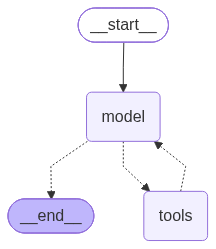

In [ ]:
from langchain.tools import tool
from langchain.agents import create_agent
from langchain.messages import HumanMessage, ToolMessage


@tool
def search_documents(query: str) -> str:
    """AI 산업 동향 보고서에서 질문과 관련된 문서 청크를 검색합니다.

    Args:
        query: 검색할 질문 또는 키워드. 완성된 질문 형태일수록 좋습니다.

    Returns:
        검색된 문서 청크 (XML 형식)
    """
    return format_docs(ensemble_retriever.invoke(query))


AGENT_SYSTEM = '''당신은 QA(Question-Answering)를 수행하는 Assistant입니다.
search_documents 툴로 보고서를 검색한 뒤, 검색 결과를 바탕으로 답변하세요.
한 번만 검색하지 말고, 추가 정보를 얻을 만한 쿼리를 선정하여 최대 세 번까지 검색하세요.
검색 결과 전체에 관련 정보가 없다면 "정보가 부족하여 답변할 수 없습니다."만 출력하세요.'''

agent = create_agent(llm, tools=[search_documents], system_prompt=AGENT_SYSTEM)
agent

In [ ]:
# 툴 호출과 최종 답변 과정을 단계별로 확인합니다
sample_q = "트럼프 미국 대통령이 서명한 '제네시스 미션' 행정명령의 핵심 목표는 무엇인가요?"

for chunk in agent.stream({"messages": [HumanMessage(sample_q)]}, stream_mode="updates"):
    for step, data in chunk.items():
        message = data['messages'][-1]
        print(f"step: {step}")
        text = message.text
        if len(text) > 500:
            print(f"    content: {text[:500]} ... (중략)")
        else:
            print(f"    content: {text}")
        if step == 'model' and message.tool_calls:
            print("    tool_calls:", message.tool_calls)
        print('-------------')

step: model
    content: 
    tool_calls: [{'name': 'search_documents', 'args': {'query': "트럼프 '제네시스 미션' 행정명령 핵심 목표"}, 'id': 'call_05KYqUfqcZm0kX5IfTEFOk8L', 'type': 'tool_call'}, {'name': 'search_documents', 'args': {'query': 'Genesis Mission 행정명령 핵심 목표 무엇'}, 'id': 'call_HVH5uw8BgfW4EVGl3S2wLUwf', 'type': 'tool_call'}, {'name': 'search_documents', 'args': {'query': '제네시스 미션(Genesis Mission) executive order Trump goal'}, 'id': 'call_SXSgVeaoyfJkhpbW6NzlJNZ8', 'type': 'tool_call'}]
-------------
step: tools
    content: <documents>
  <document index="1">
    <meta name="source">data/markdowns/SPRi AI Brief_1월호_산업동향_0102_F.md</meta>
    <content>이 내용은 2026년 1월호 SPRi AI Brief의 정책·법제 섹션 내 트럼프 미국 대통령 관련 '제네시스 미션' 행정명령에 관한 부분으로, 도널드 트럼프 대통령이 국가적 AI 과학 혁신 프로젝트인 제네시스 미션을 출범시켰음을 다룬다. 추진 체계는 미국 에너지부가 중심이 되어 과학안보 플랫폼을 구축·운영하며, 대통령 과학기술 보좌관과 국가과학기술위원회가 부처 간 조정을 총괄한다.

- n
- 도널드 트럼프 미국 대통령이 AI 기반 과학적 발견을 촉진해 미국의 기술적 우위와 글로벌 리더십을 강화하기 위한 국가적 프로젝트인 '제네시스 미션(Genesis Mission)' 출범 행정명령*에 서명 * Launching 

In [ ]:
def agent_rag_batch(questions):
    """Agent를 실행하고 (최종 답변, 툴 호출로 받은 검색 결과)를 반환합니다."""
    inputs = [{"messages": [HumanMessage(q)]} for q in questions]
    answers = [None] * len(questions)
    contexts = [None] * len(questions)

    for idx, output in tqdm(agent.batch_as_completed(inputs,
                                                    config={"recursion_limit": 10},
                                                    return_exceptions=True),
                            total=len(inputs), desc="Agent RAG"):
        if isinstance(output, Exception):
            print(f"#{idx} 실패: {type(output).__name__}")
            answers[idx] = "정보가 부족하여 답변할 수 없습니다."
            contexts[idx] = ["(검색 결과 없음)"]
            continue
        messages = output["messages"]
        answers[idx] = messages[-1].text
        # 툴 호출 횟수 = 검색 횟수
        contexts[idx] = [m.text for m in messages if isinstance(m, ToolMessage)] or ["(검색 결과 없음)"]

    return answers, contexts


await evaluate_rag('agent', agent_rag_batch)

Agent RAG: 100%|██████████| 20/20 [00:56<00:00,  2.84s/it]


Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[49]: IncompleteOutputException(The output is incomplete due to a max_tokens length limit.)


{'bleu_score': 0.2367, 'context_recall': 0.8724, 'semantic_similarity': 0.8275, 'faithfulness': 0.7952, 'factual_correctness(mode=f1)': 0.8168}

## [부록] 실제 데이터에서 중요한 패턴들

- Time 메타데이터를 이용한 사전 필터링
- RAG 여부를 사전 판단하거나, 여러 개의 Vector DB 중 어느 DB를 검색할지 판단하는 단계
- 질문과 문서의 언어 일치 (한국어 --> 영어 변환 후 검색)